
# 🌲 Random Forest Experiment 


---

## 本 notebook 覆盖的任务



Random Forest Experiment 
- **1.1 Brief Introduction of RF (main idea & parameters)
- **1.2 RF for Classification with cross validation (iris, Decision surface plot)
- **1.3 List the most important top-10 features by RF and introduce the selection strategy
- **1.4 RF for Regression (boston, scatter curve plot)
- **1.5* Explore RF with different parameters (boston, scatter curve plot)  
  
   
随机森林实验 
- **1.1 随机森林简介（核心思想与参数）
- **1.2 基于交叉验证的随机森林分类（Iris数据集，决策边界可视化）
- **1.3 列出随机森林选出的 Top-10 重要特征，并介绍其选择策略
- **1.4 随机森林回归（Boston数据集，散点曲线图）
- **1.5* 探索不同参数设置下的随机森林表现（Boston数据集，散点曲线图）



---

## 学习目标

学完这一份 notebook，你应该能回答这些问题：

1. 随机森林为什么叫“森林”？
2. 它为什么既能做分类，又能做回归？
3. 交叉验证是什么，为什么要用它？
4. 特征重要性是怎么来的，怎么用它做特征选择？
5. `n_estimators`、`max_depth`、`min_samples_leaf` 这些参数会影响什么？

---

## 代码流程


1. **先看 markdown**：知道这段代码的目的和原因  
2. **再运行代码**：看输出、看图、看指标  
3. **最后做解释**：把结果和概念联系起来





## 📦 环境说明

建议环境：

```bash
pip install numpy pandas matplotlib scikit-learn jupyter
```

> 说明：  
> - 本实验主要使用 `scikit-learn`。  
> - 分类部分用 `Iris`  数据集。  
> - 回归部分按任务要求使用 **Boston Housing**。  
> - 新版本 `scikit-learn` 已删除 `load_boston()`，所以这里采用 **本地 CSV 优先、网络读取备用** 的方式。

  





- 检查 Python、系统、`scikit-learn` 的版本
- 导入本实验需要的库和工具函数



In [2]:

# ============================
# 模块：环境检查 + 导入库
# 任务：保证后续实验可以顺利运行
# ============================

import os
import sys
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn import __version__ as sklearn_version
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)

# 为了让结果尽量可复现，我们固定随机种子
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Python version:", sys.version.split()[0])
print("Platform:", platform.platform())
print("scikit-learn version:", sklearn_version)
print("当前工作目录:", os.getcwd())


Python version: 3.9.25
Platform: macOS-15.6-arm64-arm-64bit
scikit-learn version: 1.6.1
当前工作目录: /Users/typonull/Downloads/downloads/zenfix0414


#### 结果解释与分析

这一段输出说明当前 Notebook 的运行环境已经准备好，`Python`、操作系统和 `scikit-learn` 版本都被正确识别出来了。  
教学上这一步的意义是：先确认实验环境是否可用，避免后面代码报错时不知道是代码问题还是环境问题。  
如果这里能正常输出版本信息，通常就说明后续随机森林分类与回归实验可以继续进行。


# 1.1 Brief Introduction of RF（主思想 + 参数）

## 1）什么是随机森林？

随机森林（Random Forest）本质上是：

> **很多棵决策树一起做判断，最后把结果汇总。**

- 在**分类任务**里：让很多棵树投票，票数最多的类别作为最终结果
- 在**回归任务**里：让很多棵树各自给出一个数值，最后取平均

你可以把它理解成：

- **一棵树**：像一个学生单独答题
- **随机森林**：像一群学生各自先独立答题，再集体给出答案

通常，**一群“有差异”的树一起判断**，会比单棵树更稳定。

---

## 2）随机森林为什么有效？

随机森林里每棵树都不是完全一样的，它们的差异主要来自两件事：

### 第一种随机：样本随机（Bootstrap）
每棵树训练时，不是固定拿全部样本，而是对训练样本做**有放回抽样**。

### 第二种随机：特征随机
每次分裂时，不是把所有特征都拿来比较，而是只随机看一部分特征。

这样做的好处是：
- 树和树之间不会太像
- 集成起来更稳定
- 更不容易过拟合

---


## 3）建模三步法
### 第一步：随机采样  
对原始数据集进行随机采样，得到多个训练子集
### 第二步：训练决策树  
在各个训练子集上训练得到不同的决策树模型
### 组合模型
将多个决策树模型组合，得到输出结果

---
## 4）随机森林的常用参数


| 参数 | 含义 | 初学者怎么理解 |
|---|---|---|
| `n_estimators` | 森林里树的数量 | 树越多，通常越稳定，但训练更慢 |
| `max_depth` | 每棵树最大深度 | 太深容易过拟合，太浅可能欠拟合 |
| `min_samples_split` | 一个节点至少多少样本才允许继续分裂 | 越大越保守 |
| `min_samples_leaf` | 叶子节点最少样本数 | 越大越平滑，不容易学得太碎 |
| `max_features` | 每次分裂最多看多少个特征 | 随机性的重要来源 |
| `bootstrap` | 是否采用有放回抽样 | RF 默认通常为 True |
| `oob_score` | 是否计算袋外分数 | 可以在不额外验证集时给出泛化参考 |
| `random_state` | 随机种子 | 保证实验可复现 |

---


## 5）简单来说

> 随机森林 = **多棵树 + 样本随机 + 特征随机 + 集体决策**



### 本代码块做什么？

用一个很小的例子演示 **Bootstrap（有放回抽样）**。

### 为什么要做这个小实验？

因为“样本随机”是随机森林的核心之一。  
很多初学者看到这个词时会觉得抽象，所以我们先不训练模型，只看抽样结果。

### 运行后重点看什么？

- 原始样本有没有重复？
- 抽样后的结果里有没有重复编号？
- 有没有一些原始样本根本没被抽到？

这三个现象正好对应随机森林中的：
- 重复采样
- 袋外样本（OOB）
- 树之间的差异来源


In [3]:

# ============================
# 模块：Bootstrap 演示
# 任务：理解“有放回抽样”
# ============================

# 假设原始训练集中只有 10 个样本，编号为 1~10
original_samples = np.arange(1, 11)

# 有放回抽样：抽 10 次，每次抽完还放回去，因此后面还可能再次抽到同一个样本
bootstrap_sample = np.random.choice(original_samples, size=10, replace=True)

print("原始样本:", original_samples)
print("Bootstrap 抽样结果:", bootstrap_sample)

# 看哪些样本被抽到了，哪些样本没有被抽到
selected_set = set(bootstrap_sample.tolist())
oob_samples = [x for x in original_samples if x not in selected_set]

print("被抽到过的样本:", sorted(selected_set))
print("没有被这次抽到的样本（OOB 候选）:", oob_samples)


原始样本: [ 1  2  3  4  5  6  7  8  9 10]
Bootstrap 抽样结果: [ 7  4  8  5  7 10  3  7  8  5]
被抽到过的样本: [3, 4, 5, 7, 8, 10]
没有被这次抽到的样本（OOB 候选）: [np.int64(1), np.int64(2), np.int64(6), np.int64(9)]


#### 结果解释与分析

这段结果直观展示了 **Bootstrap 有放回抽样** 的特点：同一个样本可以被重复抽到，而另一些样本可能一次都没有被抽到。  
例如当前输出里，某些编号重复出现，而 `1、2、6、9` 这几个样本没有被这次抽到，它们就是这棵树的 **OOB（袋外）候选样本**。  
这说明随机森林中每棵树看到的训练数据并不是完全相同的原始数据，而是原始数据的一个“重采样版本”，这正是森林中不同树能够形成差异的重要原因。


# 1.2 RF for Classification with Cross Validation（Iris 分类）

我们先做最经典的入门任务：**鸢尾花 Iris 分类**。

Iris 数据集有：
- 150 个样本
- 3 个类别
- 4 个特征

它非常适合作为分类入门，因为：
- 数据量小，运行快
- 结构清晰
- 非常适合画图

---

## 先解释一个重要概念：什么是交叉验证？

交叉验证（Cross Validation）可以理解为：

> 不是只随机切一次训练集/验证集，而是把数据分成几份，轮流让每一份做验证，其余部分做训练，最后把多次结果取平均。

比如 **5 折交叉验证**：
- 第 1 次：第 1 份做验证，其余 4 份训练
- 第 2 次：第 2 份做验证，其余 4 份训练
- ...
- 第 5 次：第 5 份做验证，其余 4 份训练

### 为什么要这样做？

因为如果你只切一次：
- 运气好，分得容易，分数可能偏高
- 运气不好，分得困难，分数可能偏低

交叉验证的作用就是：

- **结果更稳**
- **减少一次随机划分带来的偶然性**
- **更适合教学时比较模型**

---

## 任务

1. 先认识 Iris 数据
2. 训练一个随机森林分类器
3. 用交叉验证评估它
4. 看混淆矩阵和分类报告
5. 画决策边界图（Decision Surface Plot）

这样你不只是“得到准确率”，还能看到模型到底是怎么分区域的。



### 读取 Iris 数据集

- 看数据形状、类别名称、前几行样本

### 认识数据

- 有多少样本
- 有多少特征
- 目标变量是什么
- 每个类别大概是什么

### 运行后重点看什么？

- `X` 的行数和列数
- 类别名称
- 前几行数据长什么样


In [63]:

# ============================
# 模块：读取 Iris 数据
# 任务：先认识分类数据集
# ============================

iris = load_iris()
X_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
y_iris = pd.Series(iris.target, name="target")

print("Iris 特征矩阵形状:", X_iris.shape)
print("Iris 类别名称:", iris.target_names)
print("Iris 特征名称:", iris.feature_names)
print()
display(X_iris.head())
display(y_iris.head())


Iris 特征矩阵形状: (150, 4)
Iris 类别名称: ['setosa' 'versicolor' 'virginica']
Iris 特征名称: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

#### 结果解释与分析

从输出可以看到，Iris 数据集共有 **150 条样本、4 个特征、3 个类别**。  
这说明它是一个规模小、结构清晰、非常适合入门教学的经典分类数据集。  
前几行特征数据也能帮助学生建立直观认识：模型并不是直接处理“花的名字”，而是根据花萼和花瓣的数值特征来学习分类规则。


### 随机森林分类器

先做一次**训练集 / 测试集划分**，训练一个基础的随机森林分类器。


### 运行后重点看什么？

- 训练集和测试集分别有多少样本
- 模型在测试集上的准确率大概是多少


In [5]:

# ============================
# 模块：基础分类流程
# 任务：先完成一次最基本的训练和预测
# ============================

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_iris  # 分类任务里常用，保证各类别比例尽量一致
)

# 构建一个基础随机森林分类器
rf_clf = RandomForestClassifier(
    n_estimators=200,      # 树的数量
    max_depth=None,        # 树不限制深度
    random_state=RANDOM_STATE
)

# 在训练集上学习
rf_clf.fit(X_train_i, y_train_i)

# 在测试集上做预测
y_pred_i = rf_clf.predict(X_test_i)

# 计算准确率
acc = accuracy_score(y_test_i, y_pred_i)

print("训练集大小:", X_train_i.shape)
print("测试集大小:", X_test_i.shape)
print(f"测试集准确率 Accuracy = {acc:.4f}")


训练集大小: (120, 4)
测试集大小: (30, 4)
测试集准确率 Accuracy = 0.9000


#### 结果解释与分析

这一段完成了最基础的一次“训练—预测—评估”流程。  
当前结果中，测试集准确率约为 **0.90**，说明随机森林已经能够较好地区分三类鸢尾花。  
需要提醒学生的是：这只是一次固定划分下的结果，能够说明模型“基本有效”，但还不能说明结果一定非常稳定，所以后面还需要交叉验证做更稳健的评估。


### 评估随机森林分类器

使用 **5 折交叉验证** 来重新评估随机森林分类器。

### 为什么还要再做交叉验证？

因为刚才那一个准确率，只来自**一次切分**。  
它能帮助你建立流程感，但还不够稳。

交叉验证的意义是：
- 多次切分、多次评估
- 看平均表现
- 看结果波动

### 运行后重点看什么？

- 每一折的准确率是否接近
- 平均准确率高不高
- 标准差大不大

如果均值高、标准差小，说明模型**不仅有效，而且稳定**。


In [6]:

# ============================
# 模块：交叉验证
# 任务：让分类评估更稳、更可信
# ============================

# KFold 表示“分成多少折”
# shuffle=True 表示先打乱
# random_state 固定随机性，便于复现
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    rf_clf,          # 要评估的模型
    X_iris,          # 全部特征
    y_iris,          # 全部标签
    cv=cv,           # 5 折交叉验证
    scoring="accuracy"
)

print("5 折交叉验证每一折的准确率:", np.round(cv_scores, 4))
print(f"平均准确率: {cv_scores.mean():.4f}")
print(f"标准差: {cv_scores.std():.4f}")


5 折交叉验证每一折的准确率: [1.     0.9667 0.9333 0.9333 0.9667]
平均准确率: 0.9600
标准差: 0.0249


#### 结果解释与分析

5 折交叉验证结果分别约为 **1.00、0.97、0.93、0.93、0.97**，平均准确率约 **0.96**，标准差约 **0.025**。  
这说明随机森林在 Iris 数据集上的分类性能不仅较高，而且不同折之间波动不大，整体表现比较稳定。  
教学上这里最重要的结论是：相比单次划分，交叉验证更能反映模型的真实水平，因此它比只看一次测试集准确率更可靠。

随机森林在 Iris 数据集上准确率较高，平均性能很好，而且在不同折上的波动较小，所以这个模型的结果是比较稳定、比较可信的。


### 

输出**混淆矩阵**和**分类报告**。

### 为什么要看这些？

因为准确率只告诉你“总体对了多少”，但不告诉你：
- 哪一类最容易分错
- 错成了哪一类
- 各类别的 precision / recall / F1 分别怎样

所以教学里，准确率之后最好再补这两个工具。

### 运行后重点看什么？

- 混淆矩阵对角线是否大
- 哪两个类别更容易混淆
- 分类报告中各类的 precision / recall 是否均衡


混淆矩阵:
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]

分类报告:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



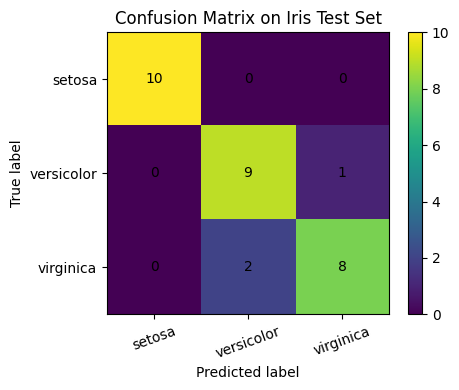

In [7]:

# ============================
# 模块：分类结果细看
# 任务：不只看准确率，还看错在哪里
# ============================

cm = confusion_matrix(y_test_i, y_pred_i)

print("混淆矩阵:")
print(cm)
print()
print("分类报告:")
print(classification_report(y_test_i, y_pred_i, target_names=iris.target_names))

# 画混淆矩阵热力图（用 matplotlib，避免依赖更多绘图库）
plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix on Iris Test Set")
plt.colorbar()
plt.xticks([0, 1, 2], iris.target_names, rotation=20)
plt.yticks([0, 1, 2], iris.target_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")

# 在格子中写数值，方便学生观察
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


#### 结果解释与分析

混淆矩阵显示，`setosa` 的 10 个样本全部分类正确，而 `versicolor` 和 `virginica` 之间存在少量混淆。  
分类报告进一步说明了这一点：`setosa` 的 precision、recall、f1-score 都是 **1.00**；而 `versicolor` 和 `virginica` 的指标略低。  
这说明随机森林整体分类效果不错，但不同类别的难度并不完全相同，真正容易混淆的是后两类，而不是 `setosa`。

setosa 最容易分类  
versicolor 和 virginica 最容易互相混淆  
模型整体表现不错，setosa 完全分对，主要错误集中在 versicolor 和 virginica 之间。  

Precision（精确率）模型预测成这一类的样本里，真正属于这一类的有多少  
Recall（召回率）真实属于这一类的样本里，模型成功找回了多少  
F1-score 是 Precision 和 Recall 的综合指标。  
Support 表示测试集中这一类真实样本有多少个。  

### 随机森林里的一棵树长什么样？

虽然随机森林是“很多棵树”，但我们可以抽出其中一棵树来看看。  
这样学生会明白：

- 每棵树本质上仍然是决策树
- 随机森林只是把很多棵“稍微不同”的树组合了起来

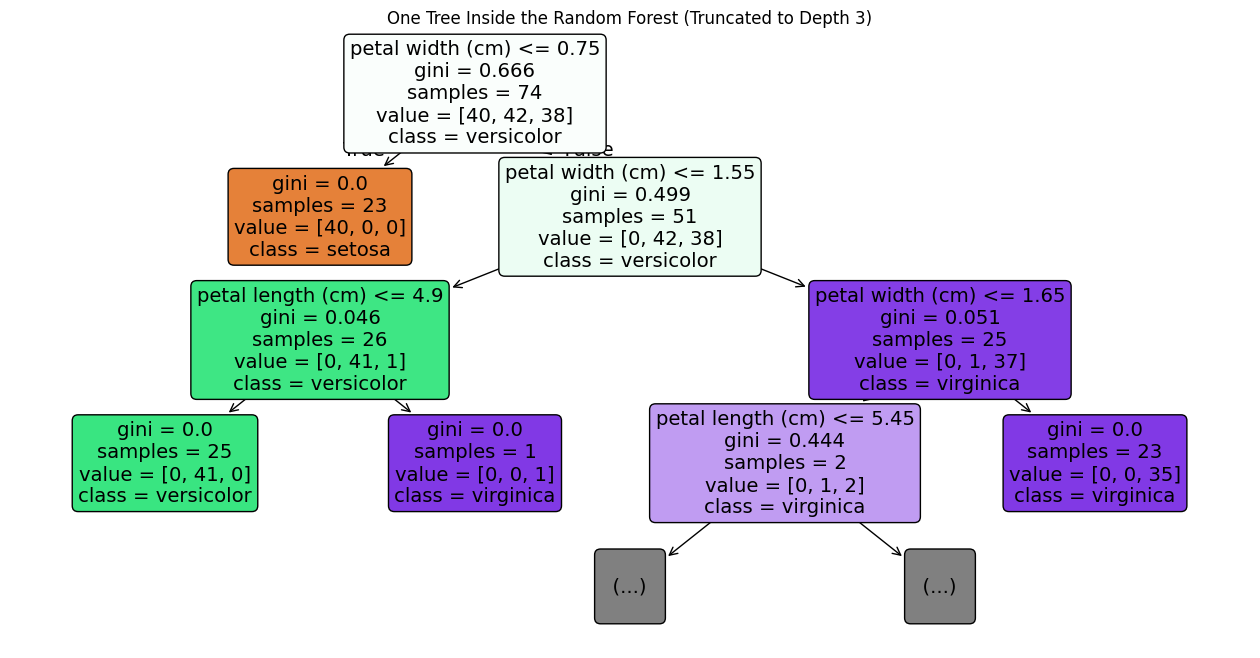

In [57]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# 如果前面已经训练过 rf_clf，就不需要再 fit 一次
single_tree = rf_clf.estimators_[0]

plt.figure(figsize=(16, 8))
plot_tree(
    single_tree,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    max_depth=3
)
plt.title("One Tree Inside the Random Forest (Truncated to Depth 3)")
plt.show()

#### 结果解释与分析

这张图展示的是**随机森林中的一棵单独决策树**，它只用于帮助理解单棵树如何一步步做判断。  
从图中通常可以看到，树会优先使用 `petal length`、`petal width` 这类区分能力更强的特征进行分裂，这与前面的分类结果是一致的。  
需要特别强调：**这棵树不代表整个随机森林**，真正的随机森林预测结果来自很多棵树共同投票；把一棵树画出来只是为了帮助学生理解模型内部机制。


### 决策边界图

画 **Decision Surface Plot（决策边界图）**。

### 为什么这里只选 2 个特征？

因为只有二维平面才能直接画出“区域划分图”。  
Iris 原本有 4 个特征，但 4 维空间没法直接像平面图那样直观看。

所以我们选其中 2 个特征：
- petal length（花瓣长度）
- petal width（花瓣宽度）

这两个特征区分能力通常也比较强，画图效果比较清楚。

### 运行后重点看什么？

- 不同颜色区域如何划分
- 样本点是否大多落在正确区域
- 类之间的边界是否清晰

这张图能帮助学生把“模型在做分类”真正可视化。


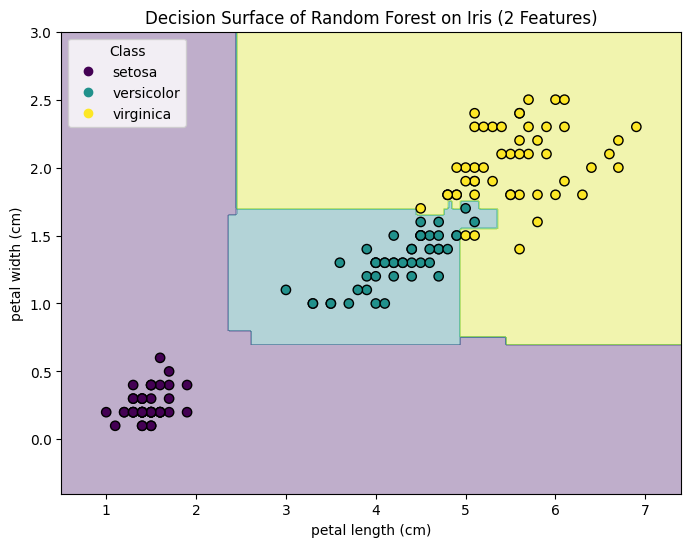

In [8]:

# ============================
# 模块：二维决策边界图
# 任务：把分类结果画成“区域”
# ============================

# 只取两个特征，方便画二维图
feature_idx = [2, 3]  # petal length, petal width
X_2d = iris.data[:, feature_idx]
y_2d = iris.target

rf_2d = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE
)
rf_2d.fit(X_2d, y_2d)

# 生成二维网格，预测网格上每个点的类别
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = rf_2d.predict(grid_points).reshape(xx.shape)

plt.figure(figsize=(8, 6))

# 先画背景分类区域
plt.contourf(xx, yy, Z, alpha=0.35)

# 再把真实样本点画上去
scatter = plt.scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=y_2d,
    edgecolor="k",
    s=45
)

plt.xlabel(iris.feature_names[feature_idx[0]])
plt.ylabel(iris.feature_names[feature_idx[1]])
plt.title("Decision Surface of Random Forest on Iris (2 Features)")
handles, _ = scatter.legend_elements()
plt.legend(handles, iris.target_names.tolist(), title="Class")
plt.show()


#### 结果解释与分析

二维决策边界图把分类结果画成了“区域”。  
从图中可以看出，`setosa` 往往位于左下角，与另外两类分隔明显，因此最容易被正确分类；而 `versicolor` 和 `virginica` 主要分布在中间和右上区域，边界附近存在一定重叠。  
这张图把前面混淆矩阵中的结论可视化了：模型总体分得不错，但真正容易混淆的仍然是 `versicolor` 和 `virginica`。

从二维决策边界图可以看出，随机森林基于花瓣长度和花瓣宽度两个特征，能够较清晰地区分三类鸢尾花。其中，setosa 位于左下区域，与另外两类分隔明显，因此最容易分类。versicolor 主要分布在中间区域，virginica 主要分布在右上区域，两者整体可分，但在边界附近仍存在一定重叠，因此更容易发生混淆。  
背景区域呈现块状和阶梯状，这是随机森林由多棵决策树进行分段划分所形成的典型特征。  
因为随机森林是由很多决策树组成的。
而决策树的切分方式本质上是：
按某个特征阈值做“横切”或“竖切”
所以单棵树形成的区域往往是矩形块状的。
很多棵树组合后，整体边界仍然会呈现出一种分段、块状、阶梯状的感觉，而不是特别平滑的曲线。
这恰好说明了随机森林的特点
它擅长做灵活、非线性的分区，但边界通常不是“数学上很光滑”的那种。


### 探索

简单探索 `n_estimators`（树的数量）对分类交叉验证结果的影响。

### 为什么补这个实验？


- 树越多越好吗？
- 10 棵树和 200 棵树差多少？
- 提高树的数量是在提升准确率，还是只是让结果更稳定？

这个小实验正好回答这些问题。

### 运行后重点看什么？

- 随着树变多，平均准确率是否提升
- 曲线是否逐渐趋于稳定


,n_estimators,cv_accuracy_mean
0,1,0.946667
1,5,0.966667
2,10,0.953333
3,30,0.960000
4,50,0.960000
5,100,0.960000
6,200,0.960000


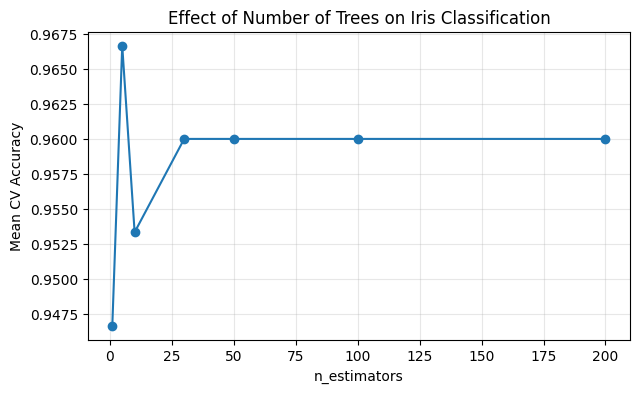

In [9]:

# ============================
# 模块：分类参数小实验
# 任务：看看树的数量对结果的影响
# ============================

tree_list = [1, 5, 10, 30, 50, 100, 200]
cv_means = []

for n_tree in tree_list:
    model = RandomForestClassifier(
        n_estimators=n_tree,
        random_state=RANDOM_STATE
    )
    scores = cross_val_score(model, X_iris, y_iris, cv=cv, scoring="accuracy")
    cv_means.append(scores.mean())

result_cls_param = pd.DataFrame({
    "n_estimators": tree_list,
    "cv_accuracy_mean": cv_means
})

display(result_cls_param)

plt.figure(figsize=(7, 4))
plt.plot(tree_list, cv_means, marker="o")
plt.xlabel("n_estimators")
plt.ylabel("Mean CV Accuracy")
plt.title("Effect of Number of Trees on Iris Classification")
plt.grid(True, alpha=0.3)
plt.show()


#### 结果解释与分析

这个参数小实验比较的是“树的数量”对分类效果的影响。  
从表格和折线图可以看出，树从 **1 棵增加到 5 棵** 时，平均准确率明显提升；之后继续增加到 **30、50、100、200** 棵，结果基本稳定在 **0.96 左右**。  
这说明随机森林并不是树越多越无限变强，而是树数增加到一定程度后性能会趋于稳定；继续增加树数，收益通常很有限。

特点 1：多棵树比单棵树更稳  
1 棵树时相对差一些，说明单树容易受个别切分影响。  
特点 2：树数增加后，模型更稳定  
从 5 棵到 30 棵之后，结果开始稳定下来。  
特点 3：树数不是越多越好，而是“够用就行”  
30、50、100、200 的结果几乎一样，说明继续加树的边际收益很小。  

# 1.3 Top-10 Features by RF + Feature Selection Strategy

Iris 只有 4 个特征，不适合演示“Top-10 特征”。  
把这一部分换成 **Boston Housing** 数据集。

这个数据集的特点：
- 一共有 **13 个特征**
- 特征数量足够展示 “Top-10 特征重要性”
- 也很适合讲 “不是所有特征都同样重要”

---

## 先讲概念：什么是特征重要性？

训练好随机森林后，可以得到每个特征的一个重要性分数。  
在回归任务里，它反映的是：

> 这个特征在森林里，平均对“减少预测误差 / 提升划分效果”贡献了多少。

简单理解：
- 分数越高，说明这个特征越常被模型用来做关键判断
- 分数越低，说明它在模型中的作用相对较小

---

## 为什么要做特征选择（Feature Selection）？

不是特征越多越好。  
有时候太多特征会带来：

- 冗余
- 噪声
- 训练更慢
- 解释更困难

所以一个常见策略是：

1. 先训练模型
2. 看特征重要性
3. 排序
4. 只保留前面最重要的若干个特征
5. 比较效果有没有明显下降

这就叫一个很基础、也很实用的**基于模型的重要性做特征选择**。

### 流程

- 读取 Boston Housing 数据集
- 看特征数量
- 训练随机森林回归器
- 计算并排序特征重要性

### 为什么这一步重要？
 
明确**哪些变量对房价预测更重要**。

### 运行后重点看什么？

- 一共有多少个特征
- 排名前 10 的特征是谁
- 重要性是不是集中在少数变量上

In [10]:
# ============================
# 模块：特征重要性准备
# 任务：用 Boston 数据集演示 Top-10 特征
# ============================

# 本地优先：适合离线环境、课程环境、作业提交环境
local_paths_fs = [
    Path("BostonHousing.csv"),
    Path("/mnt/data/BostonHousing.csv")
]

boston_fs_df = None
for p in local_paths_fs:
    if p.exists():
        boston_fs_df = pd.read_csv(p)
        print(f"✅ 从本地读取 BostonHousing.csv: {p}")
        break

# 如果本地没有，再尝试从网络读取
if boston_fs_df is None:
    backup_url_fs = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
    boston_fs_df = pd.read_csv(backup_url_fs)
    print("✅ 从网络备用地址读取 BostonHousing.csv")

X_boston_fs = boston_fs_df.drop(columns=["medv"])
y_boston_fs = boston_fs_df["medv"]

print("Boston Housing 数据形状:", X_boston_fs.shape)
print("目标变量名称:", y_boston_fs.name)
print("特征列表:", X_boston_fs.columns.tolist())

# 训练一个随机森林回归器，用来提取特征重要性
rf_boston_fs = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE
)
rf_boston_fs.fit(X_boston_fs, y_boston_fs)

# 取出特征重要性并排序
importance_df = pd.DataFrame({
    "feature": X_boston_fs.columns,
    "importance": rf_boston_fs.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

top10_df = importance_df.head(10)

display(top10_df)

✅ 从网络备用地址读取 BostonHousing.csv
Boston Housing 数据形状: (506, 13)
目标变量名称: medv
特征列表: ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat']


,feature,importance
0,rm,0.408926
1,lstat,0.397863
2,dis,0.063932
3,crim,0.037501
4,nox,0.023252
5,ptratio,0.017549
6,tax,0.014211
7,age,0.013238
8,b,0.011324
9,indus,0.005994


#### 结果解释与分析

这里使用 Boston Housing 数据集训练了一个随机森林回归器，并提取了特征重要性。  
当前结果中，最重要的两个特征是 **`rm`（平均房间数）** 和 **`lstat`（低社会经济地位人口比例）**，它们的重要性明显高于其他特征。  
这说明在当前模型里，房价预测最依赖的主要信息集中在“住房本身规模”和“社区社会经济状态”这两个方面。需要提醒学生：**特征重要性高表示模型更依赖它，不等于现实中一定存在严格因果关系。**

一、排名前十的特征

rm：每套住宅平均房间数。
lstat：低社会经济地位人口比例  
dis：到五个就业中心的加权距离  
crim：城镇人均犯罪率  
nox：一氧化氮浓度  
ptratio：城镇师生比  
tax：房产税率  
age：1940年前建成住房比例  
b：种族相关历史公式变量  
indus：非零售商业用地比例  
  
二、没有进入前十的特征  
  
zn：大面积住宅用地比例  
chas：是否临近查尔斯河（0/1）  
rad：高速公路可达性指数  

### 柱状展示

把 Boston 数据集中前 10 个最重要的特征画成柱状图。

### 为什么要画图？

表格适合精确看数值，图更适合看整体结构。  
初学者通过柱状图会更直观地看到：

- 哪些变量特别重要
- 前几名和后几名差距大不大
- 重要性是否集中

### 运行后重点看什么？

- 前 3~5 个变量是否明显更高
- Top-10 之外的变量是否可能是次要信息

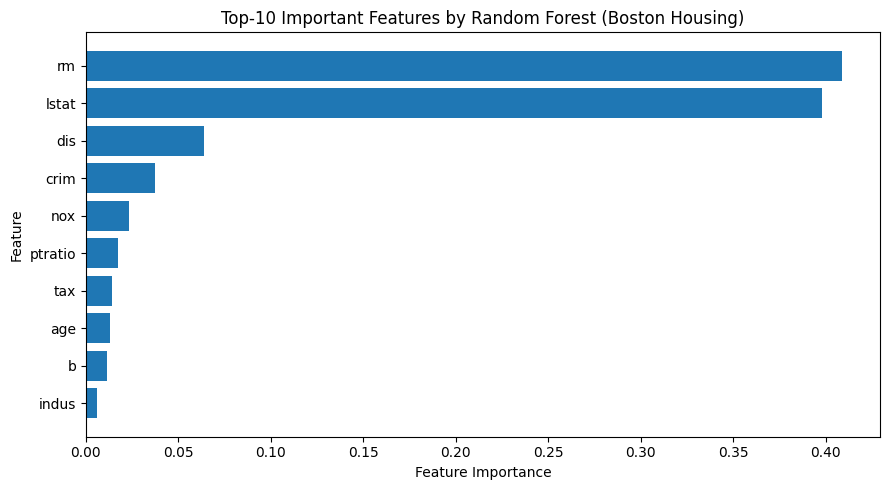

In [26]:
# ============================
# 模块：Top-10 特征可视化
# 任务：把 Boston 特征重要性画出来
# ============================

plt.figure(figsize=(9, 5))
plt.barh(top10_df["feature"][::-1], top10_df["importance"][::-1])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top-10 Important Features by Random Forest (Boston Housing)")
plt.tight_layout()
plt.show()

#### 结果解释与分析

这张柱状图把前十个最重要特征的相对贡献直观地画了出来。  
可以很清楚地看到，`rm` 和 `lstat` 的条形明显更长，说明它们在模型中的贡献远高于后面的特征；而后续特征的重要性逐渐减小，形成一种“头部很强、尾部较弱”的分布。  
教学上这张图非常适合说明：随机森林中的重要性往往不是平均分配的，而是少数关键特征占了较大贡献。

### 特征选择策略


### 策略 A：Top-k 保留法
按重要性排序后，只保留前 `k` 个特征，例如前 3、前 5、前 8、前 10。

### 策略 B：累计重要性法
把重要性从高到低累加，直到累计达到某个比例，比如 90%，就停止。

### 策略 C：验证集 / 交叉验证比较法
分别试不同的 `k`，比较模型效果，选一个“够简洁、效果又不差”的方案。

---

## 这份实验采用哪一种？

我们主要演示 **策略 A + 策略 C**：

- 先按重要性排序
- 再尝试保留前 3、5、8、10、13 个特征
- 用交叉验证比较效果



### 交叉验证比较

用不同的 `k`（保留前 k 个特征）做交叉验证比较。

### 为什么这么做？

因为“重要性高”不等于“只留这些一定最好”。  
实际中通常要**边选边验证**。

### 运行后重点看什么？

- 使用更少特征时，`R^2` 下降大不大
- 是否存在一个较小的 `k`，效果已经很接近全部特征
- 这能帮助你理解“简洁模型”与“预测性能”之间的平衡

In [27]:
# ============================
# 模块：Top-k 特征选择实验
# 任务：比较保留不同数量特征时的回归效果
# ============================

topk_list = [3, 5, 8, 10, 13]
fs_results = []

for k in topk_list:
    # 取前 k 个最重要特征
    selected_features = importance_df["feature"].head(k).tolist()
    X_selected = X_boston_fs[selected_features]

    # 用新的特征子集做交叉验证
    model = RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE
    )
    scores = cross_val_score(model, X_selected, y_boston_fs, cv=5, scoring="r2")

    fs_results.append({
        "top_k_features": k,
        "cv_r2_mean": scores.mean(),
        "cv_r2_std": scores.std()
    })

fs_df = pd.DataFrame(fs_results)
display(fs_df)

,top_k_features,cv_r2_mean,cv_r2_std
0,3,0.472591,0.383847
1,5,0.600710,0.215134
2,8,0.637679,0.198791
3,10,0.630417,0.211486
4,13,0.629307,0.207235


#### 结果解释与分析

Top-k 特征选择实验比较了保留不同数量特征时的 5 折交叉验证回归效果。  
从结果看，**Top-3** 时平均 `R²` 较低，说明特征太少会丢失较多信息；随着特征数量增加，性能不断提升，到 **Top-8** 时达到最好；之后继续增加到 **Top-10** 和 **Top-13**，效果没有继续变好。  
这说明在当前实验中，保留 **前 8 个重要特征** 在“模型简洁性”和“预测效果”之间取得了较好的平衡。

R²越大越好  
标准差越小越稳定  
结论 1  
只保留少量特征（如 Top-3）时，模型信息不足，回归效果较差。  
结论 2  
随着保留特征数量增加，模型性能先明显提升。  
结论 3  
当保留到 Top-8 时，模型达到最佳平均表现。  
结论 4  
继续增加到 Top-10 或全部 13 个特征后，性能没有进一步提升，说明部分低重要性特征贡献有限，甚至可能带来冗余。  

### 图形展示

把不同 `k` 下的交叉验证结果画出来。

### 为什么这张图很重要？

因为这张图能非常直观地回答一个常见问题：

> “我真的需要全部特征吗？”

如果曲线很早就趋于稳定，说明：
- 前面少数关键特征已经提供了大部分信息
- 后面增加的特征，边际收益可能有限

### 运行后重点看什么？

- 曲线在哪个位置开始变平
- `k=10` 和 `k=13` 差距大不大

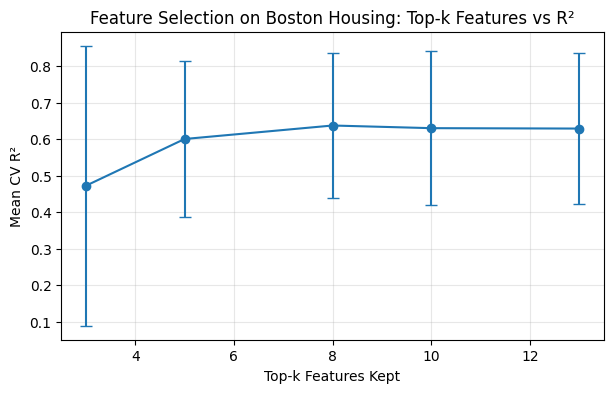

In [30]:
# ============================
# 模块：特征选择结果可视化
# 任务：观察“特征数量 vs 回归效果”
# ============================

plt.figure(figsize=(7, 4))
plt.errorbar(
    fs_df["top_k_features"],
    fs_df["cv_r2_mean"],
    yerr=fs_df["cv_r2_std"],
    marker="o",
    capsize=4
)
plt.xlabel("Top-k Features Kept")
plt.ylabel("Mean CV R²")
plt.title("Feature Selection on Boston Housing: Top-k Features vs R²")
plt.grid(True, alpha=0.3)
plt.show()

#### 结果解释与分析

误差棒图把 Top-k 实验的结果画得更直观了。  
图中的**圆点**表示平均 `R²`，上下的**误差棒**表示不同折之间的波动大小。  
从图上看，**Top-8** 不仅平均效果最好，而且波动也相对可接受；而 **Top-3** 的误差棒更长，说明不仅效果差，而且稳定性也更弱。  
因此，这张图进一步支持了前面的结论：在当前实验中，Top-8 是比较合适的特征数量。

对每一个 k：  
中间点：平均表现  
上端：平均值 + 标准差  
下端：平均值 - 标准差  

### 策略B 累计重要性

计算 **累计重要性**，作为特征选择的另一种参考视角。



### 运行后重点看什么？

- 前多少个特征就已经达到 80% 或 90%
- 是否少数变量就覆盖了大部分重要性

,feature,importance,cumulative_importance
0,rm,0.408926,0.408926
1,lstat,0.397863,0.806789
2,dis,0.063932,0.870721
3,crim,0.037501,0.908222
4,nox,0.023252,0.931474
5,ptratio,0.017549,0.949023
6,tax,0.014211,0.963234
7,age,0.013238,0.976472
8,b,0.011324,0.987796
9,indus,0.005994,0.993790


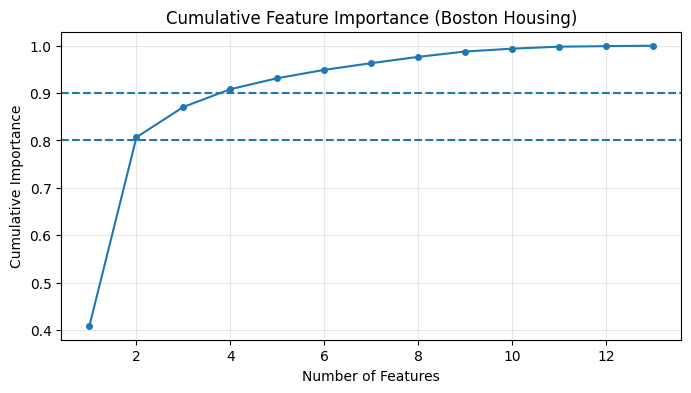

In [31]:
# ============================
# 模块：累计重要性
# 任务：从“累计贡献”角度理解 Boston 特征选择
# ============================

importance_df["cumulative_importance"] = importance_df["importance"].cumsum()
display(importance_df.head(13))

plt.figure(figsize=(8, 4))
plt.plot(
    np.arange(1, len(importance_df) + 1),
    importance_df["cumulative_importance"],
    marker="o",
    markersize=4
)
plt.axhline(0.8, linestyle="--")
plt.axhline(0.9, linestyle="--")
plt.xlabel("Number of Features")
plt.ylabel("Cumulative Importance")
plt.title("Cumulative Feature Importance (Boston Housing)")
plt.grid(True, alpha=0.3)
plt.show()

#### 结果解释与分析

累计重要性结果说明了“少数关键特征覆盖了大部分贡献”。  
当前输出中，前 **2 个特征** 的累计重要性已经超过 **80%**，前 **4 个特征** 已超过 **90%**，这说明 Boston Housing 的有效信息在模型中高度集中。  
不过也要提醒学生：**累计重要性达到 90% 并不等于预测效果一定最佳**。前面的 Top-k 实验已经表明，实际效果最好的仍然是 Top-8，因此特征选择最好结合性能验证一起看。


# 1.4 RF for Regression（Boston Housing）

**回归任务**

## 分类和回归的区别

- **分类**：预测类别  
  例如：这朵花属于哪一类？
- **回归**：预测连续数值  
  例如：这套房子的价格大概是多少？

随机森林的框架没变，但：
- 分类用 `RandomForestClassifier`
- 回归用 `RandomForestRegressor`

---

## 关于 Boston Housing 的说明

课程任务写的是 **Boston**。  
但是要注意：

- 新版 `scikit-learn` 已删除 `load_boston()`
- 原因和该数据集的历史伦理问题有关

因此这里采用更稳妥的方式：

1. **优先读取本地 `BostonHousing.csv`**
2. 若本地没有，再尝试从网络地址读取
3. 这样既能满足作业要求，也能避免版本兼容问题

---

## 任务流程

1. 读取 Boston 数据
2. 看数据概况
3. 训练随机森林回归器
4. 看回归指标
5. 画散点图和排序曲线图



### 本代码块做什么？

读取 Boston Housing 数据，并拆分成：
- 特征 `X`
- 目标变量 `y`

### 为什么要先做这一步？

因为回归任务里最关键的是先明确：

- 哪些列是输入特征
- 哪一列是你要预测的目标值

这里的目标值是 `medv`，表示房价中位数。

### 运行后重点看什么？

- 数据是否成功读取
- 特征一共有几列
- `medv` 是否存在


In [32]:

# ============================
# 模块：读取 Boston Housing 数据
# 任务：进入随机森林回归实验
# ============================

# 本地优先：适合离线环境、课程环境、作业提交环境
local_paths = [
    Path("BostonHousing.csv"),
    Path("/mnt/data/BostonHousing.csv")
]

boston_df = None
for p in local_paths:
    if p.exists():
        boston_df = pd.read_csv(p)
        print(f"✅ 从本地读取 BostonHousing.csv: {p}")
        break

# 如果本地没有，再尝试从网络读取
if boston_df is None:
    backup_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
    boston_df = pd.read_csv(backup_url)
    print("✅ 从网络读取 BostonHousing.csv")

# 统一列名风格，方便后续操作
boston_df.columns = [c.lower() for c in boston_df.columns]

# 按经典 Boston 任务设置目标变量 medv
X_boston = boston_df.drop(columns=["medv"])
y_boston = boston_df["medv"]

print("Boston 数据形状:", boston_df.shape)
print("特征数量:", X_boston.shape[1])
print("目标变量名称:", y_boston.name)
display(boston_df.head())


✅ 从网络读取 BostonHousing.csv
Boston 数据形状: (506, 14)
特征数量: 13
目标变量名称: medv


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


#### 结果解释与分析

这一段说明 Boston Housing 数据已经成功读取，并被拆分成 **13 个输入特征** 和 **1 个目标变量 `medv`**。  
从数据形状可以看到共有 **506 条样本**，这也是一个经典的小型回归教学数据集。  
前几行数据的展示作用在于：让学生知道回归模型输入的是一组数值型属性，输出的是房价中位数，而不是“房价高/低”这样的类别标签。


### 随机森林回归器

划分训练集/测试集，训练一个基础随机森林回归器，并计算常见回归指标。

### 指标


- **MAE**：平均绝对误差，平均每次大概错多少
- **RMSE**：均方根误差，对大误差更敏感
- **R²**：拟合优度，越接近 1 通常越好

### 运行后重点看什么？

- R² 是否较高
- MAE 和 RMSE 是否合理
- 训练集和测试集大小


In [45]:

# ============================
# 模块：基础回归流程
# 任务：训练随机森林回归器并做评估
# ============================

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_boston, y_boston,
    test_size=0.2,
    random_state=RANDOM_STATE
)

rf_reg = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE
)

rf_reg.fit(X_train_b, y_train_b)
y_pred_b = rf_reg.predict(X_test_b)

mae = mean_absolute_error(y_test_b, y_pred_b)
rmse = np.sqrt(mean_squared_error(y_test_b, y_pred_b))
r2 = r2_score(y_test_b, y_pred_b)

print("训练集大小:", X_train_b.shape)
print("测试集大小:", X_test_b.shape)
print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2:.4f}")


训练集大小: (404, 13)
测试集大小: (102, 13)
MAE  = 2.0853
RMSE = 3.0044
R²   = 0.8769


#### 结果解释与分析

这里完成了最基础的一次随机森林回归训练与评估。  
当前结果中，`MAE≈2.09`、`RMSE≈3.00`、`R²≈0.877`，说明模型整体已经能够较好地预测 Boston 房价。  
其中 `R²` 越接近 1 越好，表示模型对目标变量变化的解释能力越强；在当前实验里，接近 **0.88** 的 `R²` 说明模型拟合效果较好，但仍然存在一定误差。


### 散点图

画**真实值 vs 预测值**的散点图。

### 为什么这张图是回归教学里的经典图？

因为它能直接回答：

> 模型预测出来的值，和真实值到底接不接近？

如果模型很好，那么散点应该大致沿着一条对角线分布。  
因为对角线表示：**预测值 = 真实值**。

### 运行后重点看什么？

- 点是不是大致沿对角线分布
- 哪些点离对角线较远（这些是预测误差较大的样本）


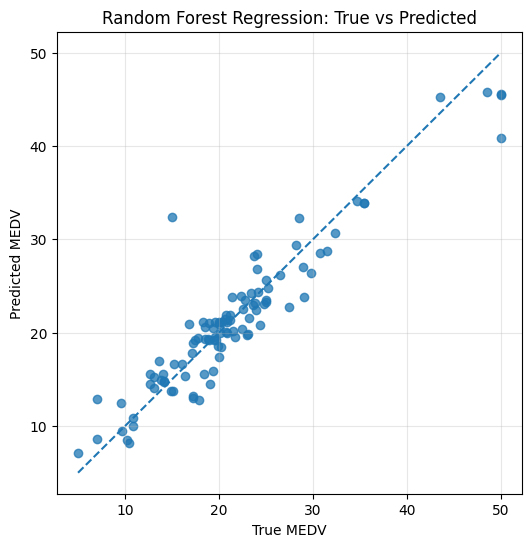

In [46]:

# ============================
# 模块：回归散点图
# 任务：直观看预测值与真实值的关系
# ============================

plt.figure(figsize=(6, 6))
plt.scatter(y_test_b, y_pred_b, alpha=0.75)

# 画一条理想参考线：预测值 = 真实值
line_min = min(y_test_b.min(), y_pred_b.min())
line_max = max(y_test_b.max(), y_pred_b.max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle="--")

plt.xlabel("True MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Random Forest Regression: True vs Predicted")
plt.grid(True, alpha=0.3)
plt.show()


#### 结果解释与分析

真实值—预测值散点图主要看“点离理想对角线有多近”。  
当前图中，大多数样本点围绕虚线分布，说明模型整体预测趋势较准确；但在高房价区域，一些点落在虚线下方，表明模型对高价房存在一定**低估**现象。  
因此，这张图说明：随机森林对整体房价趋势把握较好，但对极端高值样本的拟合还不够充分。

点越靠近虚线越好

因为虚线表示：

预测值和真实值完全一样

所以：

点在线上：预测非常准确
点离线越远：误差越大


### 整体接近程度

把测试集样本按真实值排序，然后同时画：
- 真实值曲线
- 预测值曲线

### 排序曲线图

- 模型有没有跟上整体变化趋势
- 高值区域和低值区域是否都能跟上
- 是否存在系统性偏高或偏低

### 运行后重点看什么？

- 两条线是否大致同向变化
- 在高房价或低房价区域，误差有没有变大


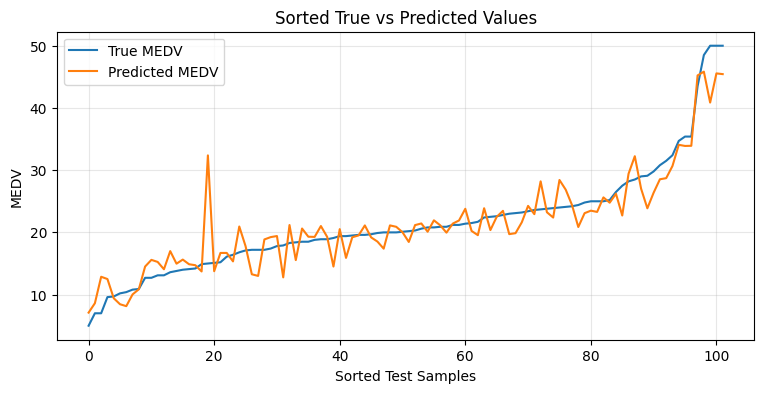

In [19]:

# ============================
# 模块：排序曲线图
# 任务：看真实值曲线和预测值曲线是否跟得上
# ============================

# 按真实值从小到大排序
sorted_idx = np.argsort(y_test_b.values)
y_true_sorted = y_test_b.values[sorted_idx]
y_pred_sorted = y_pred_b[sorted_idx]

plt.figure(figsize=(9, 4))
plt.plot(y_true_sorted, label="True MEDV")
plt.plot(y_pred_sorted, label="Predicted MEDV")
plt.xlabel("Sorted Test Samples")
plt.ylabel("MEDV")
plt.title("Sorted True vs Predicted Values")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


#### 结果解释与分析

排序曲线图把测试集真实值和预测值按真实房价从低到高排列后进行比较。  
如果两条线大体同步上升，说明模型抓住了总体趋势；如果某些局部位置偏离较大，说明这些样本误差较大。  
从当前图来看，随机森林整体能较好跟住房价变化趋势，但在高价区间仍然偏低，在部分局部样本上也存在明显偏差。

1. 两条线越接近越好

如果橙线和蓝线大部分时候贴得很近，说明：

模型预测值和真实值接近，拟合效果较好。

2. 橙线在蓝线上方

表示：

预测值比真实值大，模型高估了房价。

3. 橙线在蓝线下方

表示：

预测值比真实值小，模型低估了房价。


### 特征重要性

补充看一下**回归任务中的特征重要性**。


### 运行后重点看什么？

- 哪些变量对房价预测影响更大
- 是否少数特征占了主要贡献


,feature,importance
5,rm,0.485219
12,lstat,0.330414
7,dis,0.056777
0,crim,0.036708
10,ptratio,0.016819
4,nox,0.016775
9,tax,0.015815
6,age,0.014480
11,b,0.012769
2,indus,0.006632


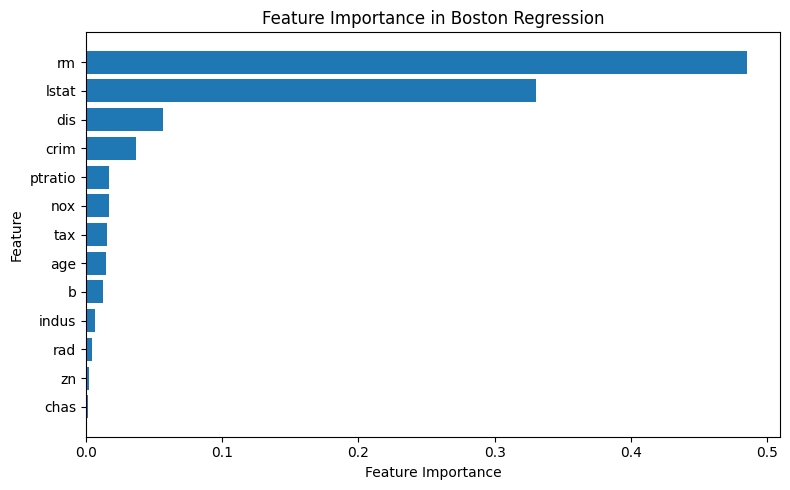

In [20]:

# ============================
# 模块：回归特征重要性
# 任务：看看哪些变量更影响房价预测
# ============================

reg_importance_df = pd.DataFrame({
    "feature": X_boston.columns,
    "importance": rf_reg.feature_importances_
}).sort_values("importance", ascending=False)

display(reg_importance_df.head(10))

plt.figure(figsize=(8, 5))
plt.barh(reg_importance_df["feature"][::-1], reg_importance_df["importance"][::-1])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance in Boston Regression")
plt.tight_layout()
plt.show()


#### 结果解释与分析

回归部分再次给出了基于 `rf_reg` 的特征重要性排序。  
结果仍然显示 **`rm` 和 `lstat`** 是最核心的两个特征，说明不管是在前面的特征选择模块，还是在正式回归建模模块中，这两个变量都 consistently 地占据主导地位。  
这也从另一个角度增强了结论的可信度：当前模型最依赖的关键信息确实主要集中在少数几个特征上。


# 1.5 Explore RF with Different Parameters（参数探索）

前面我们已经完成了一个基础随机森林回归实验。  
现在继续做一个更接近真实建模的步骤：**调参数**。

---

## 为什么要调参数？

因为模型效果并不是固定的。  
同样是随机森林，不同参数会带来不同表现。

比如：

- `n_estimators`：树的数量
- `max_depth`：树的深度
- `min_samples_leaf`：叶子节点最少样本数

不同数据集往往适合不同设置。

---

## 这一部分我们要解决什么问题？

1. 树更多时，效果会不会更稳定？
2. 树太深会不会过拟合？
3. `min_samples_leaf` 增大后，模型会不会更平滑？
4. 哪组参数在这个数据集上表现更好？

---

## 方法思路

我们这里不做复杂网格搜索，而是采用**教学友好的手工比较法**：

- 先固定大部分参数
- 一次只改一个关键参数
- 再做几组组合比较

更容易理解“参数变化 → 模型变化”。



## 实验 A：改变树的数量 `n_estimators`

先探索 `n_estimators` 对回归效果的影响。

### 为什么先看这个参数？

因为它最容易理解：

- 树太少：结果波动可能较大
- 树增多：通常更稳定
- 但增加到一定程度后，收益会变小

### 运行后重点看什么？

- R² 是否随着树增多而提升
- 曲线是否逐渐趋于平稳


,n_estimators,test_r2
0,10,0.878679
1,30,0.900262
2,50,0.898407
3,100,0.889897
4,200,0.881937
5,300,0.876909
6,500,0.877885


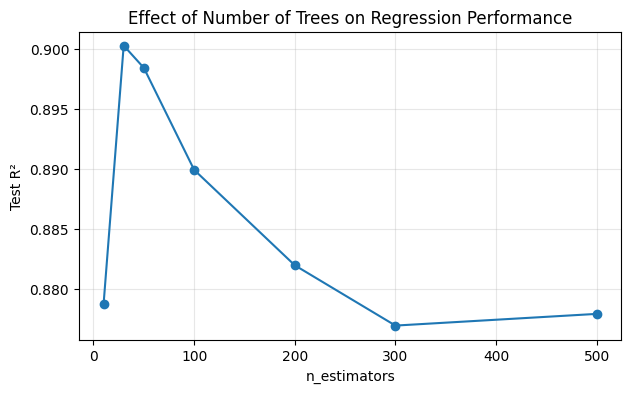

In [21]:

# ============================
# 模块：参数探索 1
# 任务：比较不同树数量的回归效果
# ============================

n_tree_list = [10, 30, 50, 100, 200, 300, 500]
r2_list = []

for n_tree in n_tree_list:
    model = RandomForestRegressor(
        n_estimators=n_tree,
        random_state=RANDOM_STATE
    )
    model.fit(X_train_b, y_train_b)
    pred = model.predict(X_test_b)
    r2_list.append(r2_score(y_test_b, pred))

param_tree_df = pd.DataFrame({
    "n_estimators": n_tree_list,
    "test_r2": r2_list
})
display(param_tree_df)

plt.figure(figsize=(7, 4))
plt.plot(n_tree_list, r2_list, marker="o")
plt.xlabel("n_estimators")
plt.ylabel("Test R²")
plt.title("Effect of Number of Trees on Regression Performance")
plt.grid(True, alpha=0.3)
plt.show()


#### 结果解释与分析

参数探索 1 比较的是不同树数量 `n_estimators` 对回归性能的影响。  
当前结果中，树数从 **10 增加到 30** 时，测试集 `R²` 明显提升；之后继续增加到 **50、100、200、300、500**，效果没有继续提高，反而有轻微波动。  
这说明在当前这次划分下，随机森林树数达到一定规模后已经足够稳定，继续增加树数并不会带来明显收益，反而只会增加计算成本。

树的数量从 10 增加到 30 时，模型效果明显提升；但继续增加到更多树后，测试集 R² 没有继续提高，反而略有下降。

也就是说，在你这次实验里：

30 棵树附近是一个比较好的点。  
从不同树数量下的回归实验结果可以看出，随机森林的测试集 R² 在树数量从 10 增加到 30 时明显提升，由 0.8787 提高到 0.9003，说明适当增加树的数量能够增强模型的稳定性和预测能力。当树数量继续增加到 50 时，模型性能基本保持在相近水平；但进一步增加到 100、200、300 和 500 时，测试集 R² 没有继续提升，反而略有下降。这表明在当前这次数据划分下，30 棵树已经能够较好地平衡模型效果与复杂度，继续增加树数量并未带来明显收益。


## 实验 B：改变树深 `max_depth`

探索 `max_depth` 对回归效果的影响。

### 为什么这个参数很重要？

因为它控制树能长多复杂。

- 太浅：表达能力不够，可能欠拟合
- 太深：模型太复杂，可能过拟合

### 运行后重点看什么？

- 哪个深度附近表现更好
- 很浅和很深的效果差异


,max_depth,test_r2
0,2,0.709983
1,3,0.818124
2,5,0.866432
3,8,0.878242
4,12,0.876718
5,None,0.876909


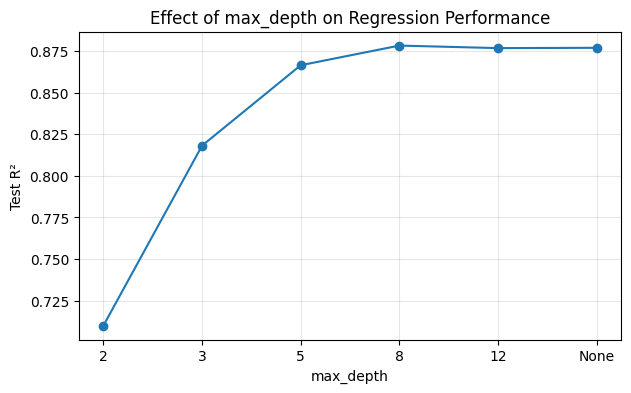

In [22]:

# ============================
# 模块：参数探索 2
# 任务：比较不同 max_depth 的效果
# ============================

depth_list = [2, 3, 5, 8, 12, None]
depth_labels = [str(x) for x in depth_list]
depth_r2 = []

for depth in depth_list:
    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=depth,
        random_state=RANDOM_STATE
    )
    model.fit(X_train_b, y_train_b)
    pred = model.predict(X_test_b)
    depth_r2.append(r2_score(y_test_b, pred))

param_depth_df = pd.DataFrame({
    "max_depth": depth_labels,
    "test_r2": depth_r2
})
display(param_depth_df)

plt.figure(figsize=(7, 4))
plt.plot(depth_labels, depth_r2, marker="o")
plt.xlabel("max_depth")
plt.ylabel("Test R²")
plt.title("Effect of max_depth on Regression Performance")
plt.grid(True, alpha=0.3)
plt.show()


#### 结果解释与分析

参数探索 2 比较的是树最大深度 `max_depth` 对回归性能的影响。  
从结果看，`max_depth=2` 时 `R²` 很低，说明树太浅会出现明显欠拟合；随着深度增加到 **3、5、8**，效果持续提升。  
当深度继续增大到 **12** 或不设限制（`None`）时，性能没有明显继续改善，这说明当前任务中树深达到一定程度后已经足够表达主要规律，再继续加深收益很有限。

从不同 max_depth 的实验结果可以看出，随机森林回归模型的测试集 R² 随着树深度增加而明显提升。当 max_depth=2 时，模型表现较差，说明树过浅导致模型表达能力不足。随着深度增加到 3、5 和 8，模型性能持续提高，表明更深的树能够学习到更复杂的房价变化规律。其中，max_depth=8 时取得了最高的测试集 R²。当深度继续增加到 12 或不设限制（None）时，性能没有进一步提升，反而略有下降，说明模型复杂度增加后收益已经很有限。总体来看，在当前实验中，max_depth=8 左右是一个较合适的设置。


## 实验 C：改变叶子节点的最少样本数 `min_samples_leaf`

探索 `min_samples_leaf` 对回归效果的影响。

### 为什么值得看这个参数？

它会限制叶子节点最少样本数。  
这个值变大后，树通常会更“保守”、更平滑。

很多时候它能帮助减轻过拟合。

### 运行后重点看什么？

- 叶子节点要求更大时，R² 是升还是降
- 是否存在一个比较合适的平衡点


,min_samples_leaf,test_r2
0,1,0.876909
1,2,0.864190
2,4,0.841346
3,6,0.827773
4,8,0.818229
5,10,0.808446


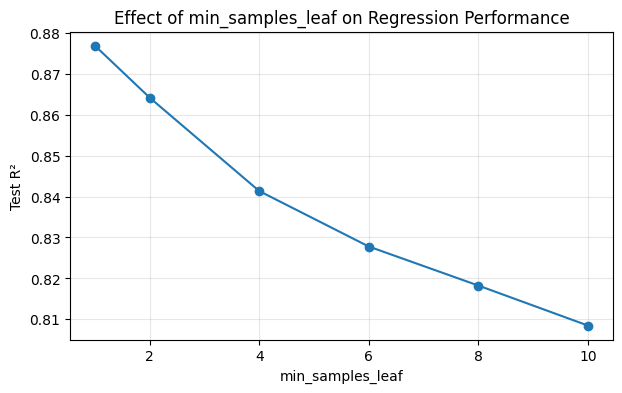

In [ ]:

# ============================
# 模块：参数探索 3
# 任务：比较不同 min_samples_leaf 的效果
# ============================

leaf_list = [1, 2, 4, 6, 8, 10]
leaf_r2 = []

for leaf in leaf_list:
    model = RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=leaf,
        random_state=RANDOM_STATE
    )
    model.fit(X_train_b, y_train_b)
    pred = model.predict(X_test_b)
    leaf_r2.append(r2_score(y_test_b, pred))

param_leaf_df = pd.DataFrame({
    "min_samples_leaf": leaf_list,
    "test_r2": leaf_r2
})
display(param_leaf_df)

plt.figure(figsize=(7, 4))
plt.plot(leaf_list, leaf_r2, marker="o")
plt.xlabel("min_samples_leaf")
plt.ylabel("Test R²")
plt.title("Effect of min_samples_leaf on Regression Performance")
plt.grid(True, alpha=0.3)
plt.show()


#### 结果解释与分析

参数探索 3 比较的是叶子节点最少样本数 `min_samples_leaf` 的影响。  
当前结果很清楚：从 **1 增加到 10**，测试集 `R²` 基本一路下降。  
这说明在当前 Boston 回归任务中，若把叶子节点限制得过大，树会分得过粗、模型表达能力下降，容易出现欠拟合；因此当前最合适的设置是较小的 `min_samples_leaf`，也就是 **1**。

从不同 min_samples_leaf 的实验结果可以看出，随着叶子节点最少样本数从 1 增加到 10，随机森林回归模型的测试集 R² 持续下降。其中，min_samples_leaf=1 时取得最高的测试集 R²，说明在当前 Boston Housing 回归任务中，允许叶子节点保留较少样本能够使模型更灵活，从而更好地拟合房价变化规律。随着 min_samples_leaf 增大，叶子节点被迫变大，树的划分变得更粗，模型表达能力下降，因此预测性能逐步减弱。这表明在当前实验中，将 min_samples_leaf 设得过大容易导致欠拟合。  
在当前 Boston 回归实验中，min_samples_leaf 越大，模型效果越差；min_samples_leaf=1 是最合适的。


### 本代码块做什么？

把几组参数组合起来做一个小型比较实验。

### 为什么还要加这一步？

前面是一维参数分析。  
但真实调参时，参数通常不是单独存在的，而是**组合影响**模型。

这一格的目的不是做“最优搜索”，而是让学生知道：

> 机器学习调参本质上是在比较不同配置的效果。

### 运行后重点看什么？

- 哪组参数表现最好
- 最好和最差配置差多少
- 参数之间会不会互相影响


In [50]:

# ============================
# 模块：参数组合比较
# 任务：更接近真实建模中的调参流程
# ============================

param_settings = [
    {"n_estimators": 50,  "max_depth": 3,   "min_samples_leaf": 1},
    {"n_estimators": 100, "max_depth": 5,   "min_samples_leaf": 1},
    {"n_estimators": 200, "max_depth": 8,   "min_samples_leaf": 2},
    {"n_estimators": 300, "max_depth": None,"min_samples_leaf": 1},
    {"n_estimators": 300, "max_depth": 8,   "min_samples_leaf": 4},
]

combo_results = []

for params in param_settings:
    model = RandomForestRegressor(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_leaf=params["min_samples_leaf"],
        random_state=RANDOM_STATE
    )
    model.fit(X_train_b, y_train_b)
    pred = model.predict(X_test_b)

    combo_results.append({
        "n_estimators": params["n_estimators"],
        "max_depth": params["max_depth"],
        "min_samples_leaf": params["min_samples_leaf"],
        "test_mae": mean_absolute_error(y_test_b, pred),
        "test_rmse": np.sqrt(mean_squared_error(y_test_b, pred)),
        "test_r2": r2_score(y_test_b, pred),
    })

combo_df = pd.DataFrame(combo_results).sort_values("test_r2", ascending=False).reset_index(drop=True)
display(combo_df)


,n_estimators,max_depth,min_samples_leaf,test_mae,test_rmse,test_r2
0,300,NaN,1,2.085307,3.004448,0.876909
1,100,5.0,1,2.221001,3.009969,0.876457
2,200,8.0,2,2.099890,3.150459,0.864655
3,300,8.0,4,2.123593,3.398408,0.842512
4,50,3.0,1,2.661802,3.532684,0.829821


#### 结果解释与分析

参数组合比较更接近真实建模中的调参过程，因为它不是只改一个参数，而是同时比较多组组合。  
当前结果显示，表现最好的配置是 **`n_estimators=300, max_depth=None, min_samples_leaf=1`**，其 `MAE`、`RMSE` 和 `R²` 都最好；表现较弱的是 **`n_estimators=50, max_depth=3, min_samples_leaf=1`**。  
这说明在当前数据上，更充分的树数和更强的表达能力确实带来了更好的整体回归表现。


### 本代码块做什么？

选出“最好的一组”和“较弱的一组”，画两张散点图做直观比较。

### 为什么要这样做？

因为表格虽然能比较数值，但图更容易帮助看出：

- 好模型和差模型的点云分布有什么区别
- 哪个模型更接近理想对角线

### 运行后重点看什么？

- 最优配置的点是否更贴近对角线
- 较弱配置是否离散得更明显


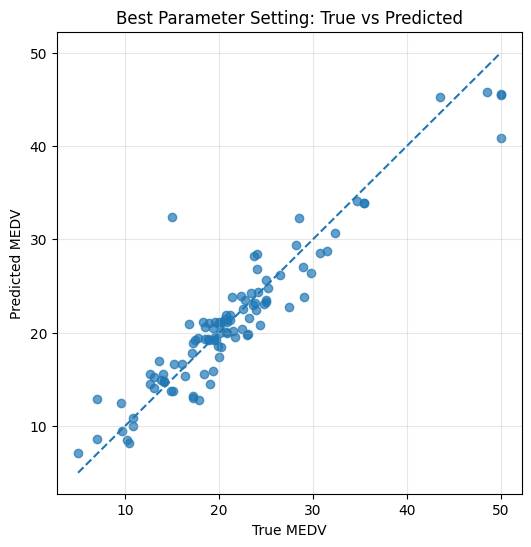

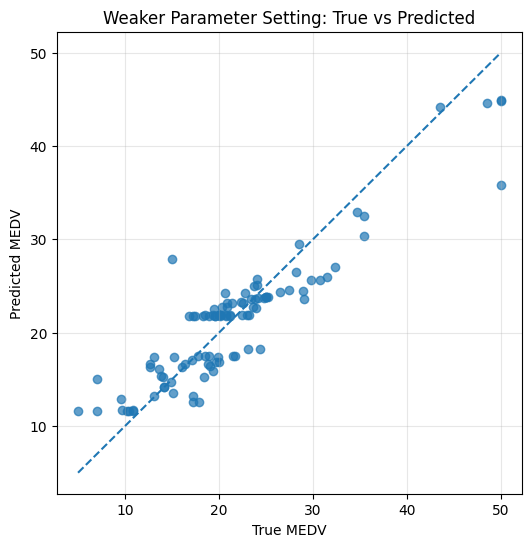

In [51]:
# ============================
# 模块：最好/较弱配置的图像对比
# 任务：把表格结果变成直观图像
# ============================

best_params = combo_df.iloc[0][["n_estimators", "max_depth", "min_samples_leaf"]].to_dict()
worst_params = combo_df.iloc[-1][["n_estimators", "max_depth", "min_samples_leaf"]].to_dict()

def safe_depth(x):
    # 如果是 NaN 或 None，就返回 None
    if pd.isna(x) or x is None:
        return None
    return int(x)

# 重新构建两个模型
best_model = RandomForestRegressor(
    n_estimators=int(best_params["n_estimators"]),
    max_depth=safe_depth(best_params["max_depth"]),
    min_samples_leaf=int(best_params["min_samples_leaf"]),
    random_state=RANDOM_STATE
)

worst_model = RandomForestRegressor(
    n_estimators=int(worst_params["n_estimators"]),
    max_depth=safe_depth(worst_params["max_depth"]),
    min_samples_leaf=int(worst_params["min_samples_leaf"]),
    random_state=RANDOM_STATE
)

best_model.fit(X_train_b, y_train_b)
worst_model.fit(X_train_b, y_train_b)

best_pred = best_model.predict(X_test_b)
worst_pred = worst_model.predict(X_test_b)

line_min = min(y_test_b.min(), best_pred.min(), worst_pred.min())
line_max = max(y_test_b.max(), best_pred.max(), worst_pred.max())

plt.figure(figsize=(6, 6))
plt.scatter(y_test_b, best_pred, alpha=0.7)
plt.plot([line_min, line_max], [line_min, line_max], linestyle="--")
plt.xlabel("True MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Best Parameter Setting: True vs Predicted")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_test_b, worst_pred, alpha=0.7)
plt.plot([line_min, line_max], [line_min, line_max], linestyle="--")
plt.xlabel("True MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Weaker Parameter Setting: True vs Predicted")
plt.grid(True, alpha=0.3)
plt.show()

#### 结果解释与分析

这两张散点图把“最好配置”和“较弱配置”的差别直接可视化了。  
在最好配置图中，更多样本点贴近理想对角线，说明预测值和真实值更加接近；而在较弱配置图中，散点更分散，偏离对角线更明显，说明误差更大。  
这种对比很适合教学：表格中的 `R²`、`MAE`、`RMSE` 是数字上的差别，而散点图把“哪个配置更贴近真实值”直观地展示出来了。


## 总结

你可以这样总结参数探索：

1. **树的数量不是越多越绝对好**，但通常越多越稳定  
2. **`max_depth` 太小会欠拟合，太大可能更复杂**  
3. **`min_samples_leaf` 会影响模型是否平滑**  
4. 调参不是“盲试”，而是带着问题去比较模型表现  
5. 真正的建模流程通常是：  
   - 先做基础模型  
   - 再看指标和图  
   - 最后有针对性地调参数



# ✅ 全文总结



## 任务内容

### 1.1 Brief Introduction of RF
- 理解了随机森林的基本思想
- 理解了样本随机、特征随机
- 认识了核心参数
- 通过小实验理解了 bootstrap 和 OOB

### 1.2 RF for Classification with cross validation
- 使用 Iris 做分类
- 完成训练/测试流程
- 理解交叉验证的概念与作用
- 画出混淆矩阵与决策边界图
- 额外探索了 `n_estimators` 对分类的影响

### 1.3 Top-10 features & selection strategy
- 使用 Boston Housing 展示 Top-10 重要特征
- 学会读取和解释 feature importance
- 学会用 Top-k 方法做特征选择
- 学会用交叉验证比较不同特征子集
- 补充了累计重要性曲线

### 1.4 RF for Regression
- 使用 Boston Housing 做回归
- 学会区分分类与回归
- 学会看 MAE、RMSE、R²
- 画了散点图和排序曲线图

### 1.5 Explore RF with different parameters
- 比较了 `n_estimators`
- 比较了 `max_depth`
- 比较了 `min_samples_leaf`
- 做了多组参数组合实验
- 用图像比较了不同配置的效果

---

## 一句话记住随机森林

> 随机森林 = **很多棵有差异的树一起学习，再把结果汇总起来。**

---


